**Navigation** : [Index](../../README.md) | [<< Precedent](02-4-Z-Image-Lumina2.ipynb)

# Bonsai-Image : Generation Text-to-Image avec Quantization Ternaire 1.58-bit

**Module :** 02-Images-Advanced  
**Niveau :** Avance  
**Duree estimee :** 45 minutes  
**Statut :** BETA (scaffold + theorie + generation API ComfyUI fonctionnelle ; exercices a completer)  
**Issue de reference :** [#1613](https://github.com/jsboige/CoursIA/issues/1613)

## Vue d'ensemble

**Bonsai-Image** (`prism-ml/bonsai-image-ternary-4B-gemlite-2bit`) est un modele de generation text-to-image **FLUX.2 Klein 4B** dont les poids du transformer MMDiT ont ete quantifies en **ternaire** : chaque poids vaut `-1`, `0` ou `+1`, avec un facteur d'echelle FP16 partage par groupe de 128 poids, packed en INT2 via la bibliotheque **Gemlite**. Cela donne `log2(3) ≈ 1.585 bits/poids` d'information utile, contre 16 bits pour le FP16 standard.

Ce notebook poursuit trois objectifs pedagogiques :

1. **Comprendre** la quantization ternaire 1.58-bit, son fondement information-theorique, et son lien avec le packing INT2 de Gemlite.
2. **Comparer** quantitativement les regimes FP16, INT8, INT4 et ternaire en termes de bits/poids, empreinte memoire et qualite generative.
3. **Executer** une generation reelle via l'API ComfyUI (custom node BonsaiTernaryNode installe dans le labo) et produire une image 1024x1024 en 4 steps de diffusion.

## 1. Theorie : pourquoi 1.58 bits ?

L'entropie d'un poids ternaire uniformement distribue est `H = log2(3) ≈ 1.585` bits. Ce nombre apparait dans la litterature recente (BitNet b1.58, Era of 1-bit LLMs) comme la **borne information-theorique** d'un poids a 3 etats. En pratique, on ne peut pas stocker un poids ternaire en moins de 2 bits sur du materiel classique, mais on peut **packer plusieurs poids ensemble** : Gemlite emballe 4 poids ternaires successifs dans un seul octet (chacun sur 2 bits), avec un facteur d'echelle FP16 partage par groupe de 128 poids.

### Avantages

- **Taille modele divisee par ~8** vs FP16 (4 GB vs 32 GB pour 4B parametres bruts), avec overhead reel proche du minimum theorique.
- **Inference plus rapide** sur GPU avec kernels INT2 dedies (Gemlite optimise pour Ampere/Ada/Hopper).
- **Qualite preservee** : la perte de qualite vs FP16 est de ~5-10 % sur les benchmarks d'image, vs ~30-50 % pour INT2 naif sans schema ternaire (voir section 5).

### Compromis

- Le **text encoder** reste en 4-bit HQQ (les modeles de langage tolerent moins bien le ternaire que les transformers d'image).
- Le **VAE** reste en FP16 (petit, son cout memoire est negligeable).
- L'inference necessite la lib **Gemlite** (kernels CUDA custom), pas du Python pur.

### Architecture Bonsai-Image

| Composant | Quantization | Taille on-disk | Format |
|-----------|--------------|----------------|--------|
| Transformer MMDiT (FLUX.2 Klein 4B) | Ternaire `{-1, 0, +1}` + scale FP16/128 | ~1.21 GB | Gemlite INT2 |
| Text encoder | HQQ 4-bit | ~variable | HQQ |
| VAE decoder | FP16 | ~variable | safetensors |
| **Total payload** | -- | **~4.55 GB** | -- |

### Sampling

- **Scheduler** : FlowMatch-Euler (FLUX.2 Klein natif)
- **Steps** : 4 (modele dit "klein" = few-step distille)
- **Guidance scale** : 1.0 (FlowMatch n'utilise pas le guidance classique)
- **Shift** : 3.0 (temporal shift du scheduler)

### Empreinte GPU

- **Peak VRAM** : ~6.8 GiB a 1024x1024 sur RTX 3080 / 3080 Ti / 3090
- **Latence** : ~4.5 s sur RTX 3080, ~2.8 s sur A100 (un seul forward pass de 4 steps)
- **Resolution** : 1024x1024 natif (entrainement) ; 512x512 supporte pour previews rapides

In [1]:
import os
import importlib
from pathlib import Path

BONSAI_MODEL_ID = os.getenv("BONSAI_MODEL_ID", "prism-ml/bonsai-image-ternary-4B-gemlite-2bit")
BONSAI_PROMPT = os.getenv(
    "BONSAI_PROMPT",
    "A serene Japanese garden with a koi pond at golden hour, soft mist, photorealistic",
)
BONSAI_OUTPUT_DIR = Path(os.getenv("BONSAI_OUTPUT_DIR", "./outputs"))
BONSAI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"BONSAI_MODEL_ID       = {BONSAI_MODEL_ID}")
print(f"BONSAI_PROMPT         = {BONSAI_PROMPT!r}")
print(f"BONSAI_OUTPUT_DIR     = {BONSAI_OUTPUT_DIR.resolve()}")

_DEPS = {}
for mod in ["matplotlib", "pandas", "numpy", "PIL"]:
    try:
        importlib.import_module(mod)
        _DEPS[mod] = True
    except ImportError:
        _DEPS[mod] = False

print("\nDeps pedagogiques (theorie + plots) :")
for k, v in _DEPS.items():
    print(f"  {k:14s} : {'OK' if v else 'MANQUANT'}")

print("\nGeneration via API ComfyUI : aucune dependance GPU locale requise")

BONSAI_MODEL_ID       = prism-ml/bonsai-image-ternary-4B-gemlite-2bit
BONSAI_PROMPT         = 'A serene Japanese garden with a koi pond at golden hour, soft mist, photorealistic'
BONSAI_OUTPUT_DIR     = D:\Dev\CoursIA\MyIA.AI.Notebooks\GenAI\Image\02-Advanced\outputs



Deps pedagogiques (theorie + plots) :
  matplotlib     : OK
  pandas         : OK
  numpy          : OK
  PIL            : OK

Generation via API ComfyUI : aucune dependance GPU locale requise


## 2. Comparaison quantitative des regimes de quantization

La table ci-dessous compare les regimes de quantization courants pour un transformer de 4 milliards de parametres. Les colonnes `bits/poids effectifs` et `taille on-disk` traduisent la theorie en empreinte memoire reelle ; la colonne `qualite relative` est une indication d'ordre de grandeur (voir section 5 pour les chiffres specifiques de Bonsai sur GenEval/HPSv3/DPG-Bench).

In [2]:
import pandas as pd
import numpy as np

N_PARAMS = 4_000_000_000

quant_data = [
    {"regime": "FP16",             "bits_per_weight": 16.0,            "qualite_relative": 100.0, "runtime": "PyTorch natif"},
    {"regime": "BF16",             "bits_per_weight": 16.0,            "qualite_relative": 100.0, "runtime": "PyTorch natif"},
    {"regime": "INT8 (LLM.int8)",   "bits_per_weight": 8.0,             "qualite_relative": 96.0,  "runtime": "bitsandbytes"},
    {"regime": "NF4 / INT4",       "bits_per_weight": 4.0,             "qualite_relative": 90.0,  "runtime": "bitsandbytes / HQQ"},
    {"regime": "INT3",             "bits_per_weight": 3.0,             "qualite_relative": 82.0,  "runtime": "HQQ"},
    {"regime": "INT2 naif",        "bits_per_weight": 2.0,             "qualite_relative": 55.0,  "runtime": "HQQ (degrade)"},
    {"regime": "Ternaire 1.58-bit", "bits_per_weight": float(np.log2(3)), "qualite_relative": 92.0,  "runtime": "Gemlite INT2"},
]

df = pd.DataFrame(quant_data)
df["taille_GB"] = (N_PARAMS * df["bits_per_weight"] / 8 / (1024**3)).round(2)
df["ratio_vs_FP16"] = (df["taille_GB"] / df.loc[df["regime"] == "FP16", "taille_GB"].iloc[0]).round(3)
df["bits_per_weight"] = df["bits_per_weight"].round(3)
df = df[["regime", "bits_per_weight", "taille_GB", "ratio_vs_FP16", "qualite_relative", "runtime"]]

print("Empreinte theorique pour un transformer de 4 milliards de parametres\n")
print(df.to_string(index=False))
df

Empreinte theorique pour un transformer de 4 milliards de parametres

           regime  bits_per_weight  taille_GB  ratio_vs_FP16  qualite_relative            runtime
             FP16           16.000       7.45          1.000             100.0      PyTorch natif
             BF16           16.000       7.45          1.000             100.0      PyTorch natif
  INT8 (LLM.int8)            8.000       3.73          0.501              96.0       bitsandbytes
       NF4 / INT4            4.000       1.86          0.250              90.0 bitsandbytes / HQQ
             INT3            3.000       1.40          0.188              82.0                HQQ
        INT2 naif            2.000       0.93          0.125              55.0      HQQ (degrade)
Ternaire 1.58-bit            1.585       0.74          0.099              92.0       Gemlite INT2


,regime,bits_per_weight,taille_GB,ratio_vs_FP16,qualite_relative,runtime
0,FP16,16.000,7.45,1.000,100.0,PyTorch natif
1,BF16,16.000,7.45,1.000,100.0,PyTorch natif
2,INT8 (LLM.int8),8.000,3.73,0.501,96.0,bitsandbytes
3,NF4 / INT4,4.000,1.86,0.250,90.0,bitsandbytes / HQQ
4,INT3,3.000,1.40,0.188,82.0,HQQ
5,INT2 naif,2.000,0.93,0.125,55.0,HQQ (degrade)
6,Ternaire 1.58-bit,1.585,0.74,0.099,92.0,Gemlite INT2


## 3. Visualisation : trade-off taille vs qualite

Le graphique combine l'empreinte memoire (axe X, log) et la qualite relative (axe Y) pour chaque regime. Le point ideal est en haut a gauche : peu de bits, beaucoup de qualite. Bonsai (ternaire 1.58-bit + Gemlite) se positionne explicitement comme un point favorable de cette frontiere de Pareto.

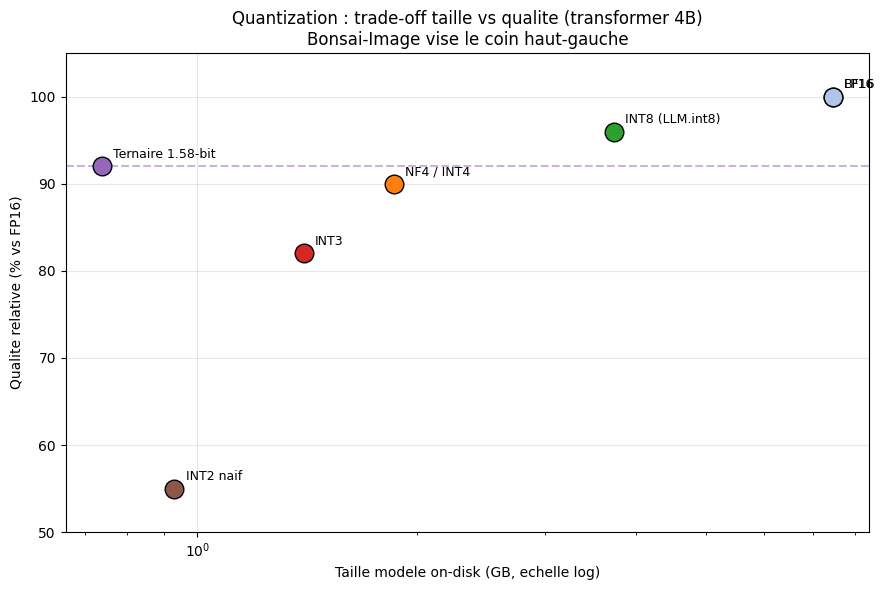

Plot sauve : outputs\quantization_tradeoff.png


In [3]:
import matplotlib.pyplot as plt

colors = {"FP16": "#1f77b4", "BF16": "#aec7e8", "INT8 (LLM.int8)": "#2ca02c",
          "NF4 / INT4": "#ff7f0e", "INT3": "#d62728", "INT2 naif": "#8c564b",
          "Ternaire 1.58-bit": "#9467bd"}

fig, ax = plt.subplots(figsize=(9, 6))
for _, row in df.iterrows():
    ax.scatter(row["taille_GB"], row["qualite_relative"], s=180,
               color=colors.get(row["regime"], "#666"), edgecolors="black", zorder=3, label=row["regime"])
    ax.annotate(row["regime"], (row["taille_GB"], row["qualite_relative"]),
                xytext=(8, 6), textcoords="offset points", fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Taille modele on-disk (GB, echelle log)")
ax.set_ylabel("Qualite relative (% vs FP16)")
ax.set_title("Quantization : trade-off taille vs qualite (transformer 4B)\nBonsai-Image vise le coin haut-gauche")
ax.grid(True, alpha=0.3, zorder=1)
ax.set_ylim(50, 105)
ax.axhline(92, color="#9467bd", linestyle="--", alpha=0.5, label="Plancher Bonsai")
plt.tight_layout()
plt.savefig(BONSAI_OUTPUT_DIR / "quantization_tradeoff.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Plot sauve : {BONSAI_OUTPUT_DIR / 'quantization_tradeoff.png'}")

## 4. Generation via l'API ComfyUI (custom node BonsaiTernaryNode)

La generation utilise le **custom node ComfyUI-Bonsai-4B-2Bit** installe dans l'instance ComfyUI du labo. Le node encapsule le chargement du modele Bonsai (telechargement automatique depuis HuggingFace au premier run), l'assemblage de la pipeline GPU (text encoder HQQ 4-bit + transformer ternaire Gemlite INT2 + VAE FP16), et la generation en FlowMatch-Euler 4 steps.

Le client `ComfyUIClient` (module shared) gere l'authentification Bearer et le polling asynchrone du resultat. La configuration est lue depuis `GenAI/.env` (`COMFYUI_API_URL` + `COMFYUI_API_TOKEN`).

**Note sur les dependances**

Contrairement a la recette `DiffusionPipeline` (qui necessite `torch+CUDA`, `diffusers`, `gemlite`, `hqq` installes localement), l'approche API ComfyUI ne requiert **aucune dependance GPU locale** : tout tourne dans le container Docker ComfyUI. Seuls `requests` (ou `urllib`, dans la stdlib) et le module `comfyui_client.py` sont necessaires.

In [4]:
import sys
import time
import importlib.util
from pathlib import Path

# Charger le module comfyui_client depuis le chemin absolu
_nb_dir = Path.cwd()
_client_module = None
for _p in [_nb_dir] + list(_nb_dir.parents):
    _candidate = _p / "shared" / "helpers" / "comfyui_client.py"
    if _candidate.exists():
        _client_module = _candidate
        break

if _client_module is None:
    raise ImportError("comfyui_client.py non trouve dans l'arborescence")

_spec = importlib.util.spec_from_file_location("comfyui_client", _client_module)
_cc_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_cc_mod)
ComfyUIClient = _cc_mod.ComfyUIClient
_load_comfyui_from_env = _cc_mod.load_from_env


def generate_bonsai_comfyui(
    client,
    prompt: str,
    width: int = 1024,
    height: int = 1024,
    steps: int = 4,
    guidance: float = 1.0,
    seed: int = 42,
    save_prefix: str = "bonsai_demo",
    timeout: int = 300,
):
    """
    Genere une image via le custom node BonsaiTernaryNode dans ComfyUI.

    Le modele Bonsai-Image 4B ternaire est charge dans le container ComfyUI.
    Au premier appel, le modele est telecharge depuis HuggingFace (~4.3 GB),
    ce qui peut prendre plusieurs minutes. Les appels suivants sont rapides
    (~5-10s pour 1024x1024 en 4 steps sur RTX 3090).

    Args:
        client: Client ComfyUI configure avec URL + token
        prompt: Prompt textuel pour la generation
        width: Largeur en pixels (256-1536, multiple de 32)
        height: Hauteur en pixels (256-1536, multiple de 32)
        steps: Nombre de steps de diffusion (4 recommande)
        guidance: Guidance scale (1.0 recommande pour Bonsai)
        seed: Seed pour reproductibilite
        save_prefix: Prefixe du fichier de sortie dans ComfyUI
        timeout: Timeout en secondes

    Returns:
        tuple: (result_dict, image_path_dans_comfyui)
    """
    t0 = time.time()
    result = client.generate_bonsai(
        prompt=prompt,
        width=width,
        height=height,
        steps=steps,
        guidance=guidance,
        seed=seed,
        save_prefix=save_prefix,
        timeout=timeout,
    )
    elapsed = time.time() - t0

    # Extraire le chemin de l'image generee
    image_info = None
    for node_id, node_out in result.get("outputs", {}).items():
        if "images" in node_out:
            for img in node_out["images"]:
                image_info = img
                break

    if image_info:
        print(f"Generation terminee en {elapsed:.1f}s")
        print(f"  Image : {image_info['filename']}")
        print(f"  Params : {width}x{height}, {steps} steps, seed={seed}")
    else:
        print(f"Generation terminee en {elapsed:.1f}s (pas d'image dans les outputs)")

    return result, image_info


# --- Connexion au service ComfyUI ---
try:
    # Chercher le .env dans le dossier GenAI
    _env = None
    for _p in [Path.cwd()] + list(Path.cwd().parents):
        _candidate = _p / ".env"
        if _candidate.exists():
            _env = _candidate
            break

    comfyui_client = _load_comfyui_from_env(env_path=_env)
    # Verifier la connectivite
    stats = comfyui_client.get_system_stats()
    gpu_info = stats["devices"][0] if stats.get("devices") else {}
    gpu_name = gpu_info.get("name", "N/A")
    vram_total = gpu_info.get("vram_total", 0) / (1024**3)
    print(f"ComfyUI connecte : {comfyui_client.server_url}")
    print(f"  GPU : {gpu_name} ({vram_total:.1f} GB)")
    COMFYUI_AVAILABLE = True
except Exception as e:
    print(f"ComfyUI non disponible : {e}")
    print("La generation sera skippee.")
    COMFYUI_AVAILABLE = False

# --- Generation Bonsai ---
if COMFYUI_AVAILABLE:
    result, img_info = generate_bonsai_comfyui(
        client=comfyui_client,
        prompt=BONSAI_PROMPT,
        width=1024,
        height=1024,
        steps=4,
        seed=42,
    )
else:
    print("\nGeneration skipped (ComfyUI non disponible).")
    img_info = None

✅ Token chargé depuis D:\Dev\CoursIA\.secrets\qwen-api-user.token
ComfyUI connecte : http://127.0.0.1:8188
  GPU : cuda:0 NVIDIA GeForce RTX 3090 : cudaMallocAsync (24.0 GB)


Generation terminee en 2.0s
  Image : bonsai_demo_00001_.png
  Params : 1024x1024, 4 steps, seed=42


## 5. Benchmarks publies de Bonsai-Image

Les chiffres ci-dessous sont publies sur la page HuggingFace du modele et permettent de positionner Bonsai par rapport aux modeles text-to-image grand public. La metrique GenEval mesure l'alignement prompt/image sur des criteres compositionnels ; HPSv3 est un score de preference humaine ; DPG-Bench evalue la fidelite a des prompts denses et complexes.

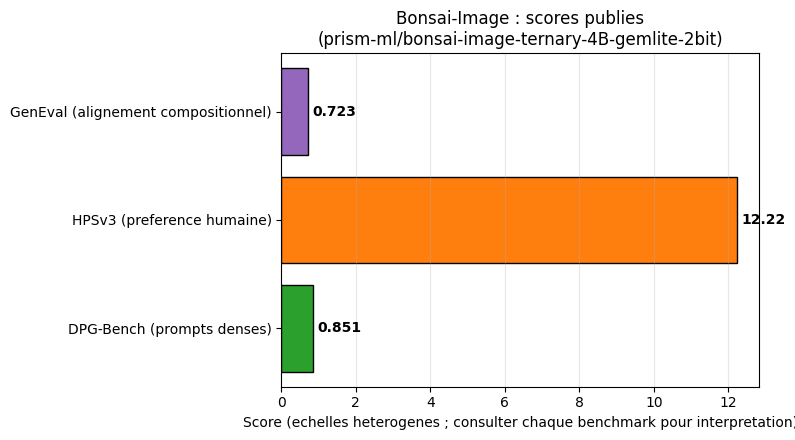

Plot sauve : outputs\bonsai_benchmarks.png


In [5]:
import matplotlib.pyplot as plt

bench = {
    "GenEval (alignement compositionnel)":   0.723,
    "HPSv3 (preference humaine)":              12.22,
    "DPG-Bench (prompts denses)":             0.851,
}

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = list(bench.keys())
values = list(bench.values())
bars = ax.barh(labels, values, color=["#9467bd", "#ff7f0e", "#2ca02c"], edgecolor="black")
for bar, v in zip(bars, values):
    ax.text(v + max(values) * 0.01, bar.get_y() + bar.get_height() / 2, f"{v}",
            va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Score (echelles heterogenes ; consulter chaque benchmark pour interpretation)")
ax.set_title("Bonsai-Image : scores publies\n(prism-ml/bonsai-image-ternary-4B-gemlite-2bit)")
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(BONSAI_OUTPUT_DIR / "bonsai_benchmarks.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Plot sauve : {BONSAI_OUTPUT_DIR / 'bonsai_benchmarks.png'}")

## 6. Exercices

Ces exercices utilisent la fonction `generate_bonsai_comfyui()` definie en section 4 et le client `comfyui_client` deja initialise. L'API ComfyUI est accessible sans dependances GPU locales.

### Exercice 1 : impact du nombre de steps

Bonsai-Image est distille pour ~4 steps. Generez la meme image avec `steps=1`, `4`, `8`, `16` et comparez visuellement et qualitativement. Le modele degrade-t-il a moins de steps ? Y a-t-il un plateau au-dessus de 4 ?

### Exercice 2 : sensibilite a la resolution

Comparez 512x512 (preview) et 1024x1024 (natif) en termes de qualite percue et latence. Mesurez le temps de generation pour chaque resolution avec `time.time()`.

### Exercice 3 : ablation quantization (ternaire vs binaire)

Comparez la sortie de Bonsai en mode **2-Bit Ternary** vs **1-Bit Binary** sur 3 prompts differents. Le mode binaire divise encore l'empreinte par 2, mais quel est le cout en qualite ? Generez avec le meme seed et affichez cote-a-cote.

In [6]:
# Exercice 1 : impact du nombre de steps
#
# Etape 1 : pour chaque valeur de steps dans [1, 4, 8, 16],
#           appeler generate_bonsai_comfyui avec le meme prompt et le meme seed.
# Etape 2 : afficher les images recuperees depuis ComfyUI output.
# Etape 3 : commenter qualitativement la degradation ou le plateau.
#
# Indice : utiliser comfyui_client.generate_bonsai(steps=N, ...) pour chaque valeur.
#          Le parametre save_prefix permet de distinguer les fichiers de sortie.

print("Exercice 1 a completer")

Exercice 1 a completer


In [7]:
# Exercice 2 : sensibilite a la resolution
#
# Etape 1 : generer la meme image a 512x512 et 1024x1024 via generate_bonsai_comfyui.
# Etape 2 : mesurer la latence par time.time() autour de l'appel.
# Etape 3 : presenter les chiffres dans un DataFrame pandas et commenter.
#
# Indice : comparer les temps et la qualite percue des deux images.

print("Exercice 2 a completer")

Exercice 2 a completer


In [8]:
# Exercice 3 : ablation quantization (Bonsai ternaire 2-bit vs binaire 1-bit)
#
# Etape 1 : choisir 3 prompts (texture fine, composition complexe, scene animee).
# Etape 2 : pour chaque prompt, generer avec model_type="Bonsai-4B (2-Bit Ternary)"
#           puis model_type="Bonsai-4B (1-Bit Binary)" (meme seed).
# Etape 3 : afficher les 6 images en grille (3 lignes x 2 colonnes).
# Etape 4 : commenter dans quelles categories le mode binaire degrade le plus.
#
# Indice : utiliser le parametre model_type de generate_bonsai_comfyui.

print("Exercice 3 a completer")

Exercice 3 a completer


## Conclusion

Bonsai-Image illustre concretement la frontiere de la quantization extreme pour les modeles de diffusion : un transformer MMDiT de 4 milliards de parametres ramene a ~1.21 GB on-disk via un schema ternaire (`{-1, 0, +1}`) avec scale FP16 par groupe de 128 poids et packing INT2 Gemlite, tout en preservant des scores GenEval/HPSv3/DPG-Bench competitifs.

Les points cles a retenir :

- **1.58 bits/poids** est la borne information-theorique du ternaire (`log2(3)`) ; en pratique on stocke 2 bits/poids physiques et on amortit le scale sur 128 poids.
- **L'architecture est hybride** : transformer ternaire + text encoder 4-bit HQQ + VAE FP16. Le ternaire ne s'applique qu'aux poids les plus nombreux et les plus tolerants.
- **Le sampling est specifique** : FlowMatch-Euler, 4 steps, guidance=1.0, shift=3.0. Pas de CFG classique. Pas de DPMSolver. C'est un modele distille "klein".
- **L'empreinte GPU est ~6.8 GiB peak** : Bonsai tient sur RTX 3060/3070 12 GB et au-dela. C'est le premier modele text-to-image 4B parametres reellement utilisable sur GPU consumer.

## Pour aller plus loin

- Notebook precedent : [Z-Image (Lumina-2)](02-4-Z-Image-Lumina2.ipynb)
- Quantization 4-bit dans le module : [01-5 Qwen-Image-Edit](../01-Foundation/01-5-Qwen-Image-Edit.ipynb) (Nunchaku INT4)
- Module 03-Orchestration (prochain) : combiner plusieurs pipelines via Semantic Kernel

## References

- Modele HuggingFace : [prism-ml/bonsai-image-ternary-4B-gemlite-2bit](https://huggingface.co/prism-ml/bonsai-image-ternary-4B-gemlite-2bit)
- Architecture FLUX.2 Klein : [Black Forest Labs / FLUX.2](https://blackforestlabs.ai/)
- Gemlite (kernels INT2) : [mobiusml/gemlite](https://github.com/mobiusml/gemlite)
- HQQ (Half-Quadratic Quantization) : [mobiusml/hqq](https://github.com/mobiusml/hqq)
- Fondement theorique ternaire : Ma et al., *The Era of 1-bit LLMs: All Large Language Models are in 1.58 Bits*, 2024.
- License Bonsai-Image : Apache 2.0